Exported: agi_concept.svg, agi_concept.png


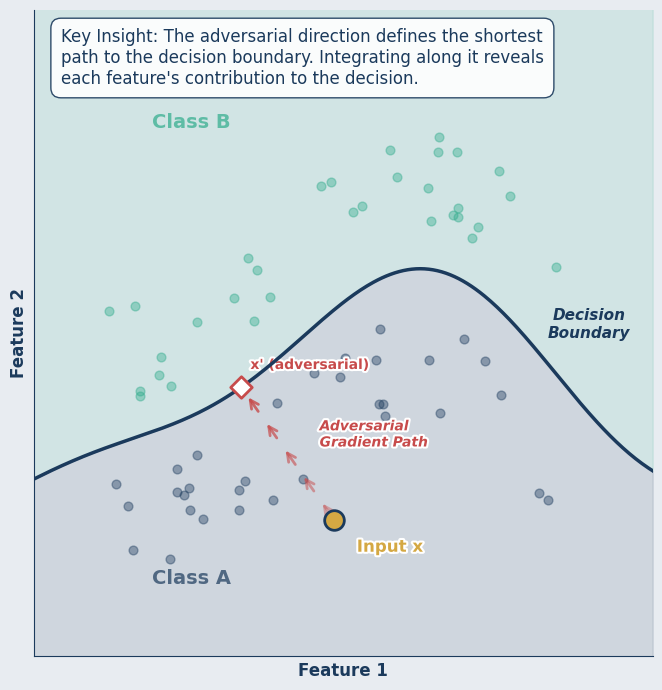

In [19]:
"""
AGI Concept Diagram — Adversarial Gradient Integration
Generates a presentation-ready diagram showing:
  - Two class regions separated by a curved decision boundary
  - An input sample with adversarial gradient arrows toward the boundary
  - An adversarial counterpart on the boundary

Usage:
  pip install -r requirements.txt
  python agi_diagram.py

Output:
  agi_concept.svg  (vector, best for PowerPoint)
  agi_concept.png  (raster, 300 dpi backup)
"""

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
import os

# ──────────────────────────────────────────────
# Saving Path
# ──────────────────────────────────────────────
saving_path = os.path.join(os.getcwd(), "saved")
# ──────────────────────────────────────────────
# COLOR PALETTE  (edit these to match your deck)
# ──────────────────────────────────────────────
BG_COLOR      = '#E8ECF1'   # slide background
NAVY          = '#1B3A5C'   # class A / decision boundary
TEAL          = '#2EAB8B'   # class B
GOLD          = '#D4A843'   # input sample highlight
RED           = '#C74B4B'   # adversarial gradient arrows
WHITE         = '#FFFFFF'
TEXT_DARK     = '#2D2D2D'   # body text

# ──────────────────────────────────────────────
# FIGURE SIZE & RESOLUTION
# ──────────────────────────────────────────────
FIG_WIDTH  = 10    # inches
FIG_HEIGHT = 7     # inches
DPI        = 300   # for PNG export

# ──────────────────────────────────────────────
# DECISION BOUNDARY CURVE
# Modify the function below to change the shape
# ──────────────────────────────────────────────
x_boundary = np.linspace(-0.5, 6.5, 300)
y_boundary = 2.5 + 1.2 * np.sin(0.7 * x_boundary - 1.0) + 0.3 * np.cos(1.5 * x_boundary)

# ──────────────────────────────────────────────
# SCATTER POINTS  (x, y arrays)
# ──────────────────────────────────────────────
np.random.seed(42)
n_pts = 32

def bnd(x):
    return 2.5 + 1.2 * np.sin(0.7 * x - 1.0) + 0.3 * np.cos(1.5 * x)

# Class A — below boundary
xa = np.random.uniform(0.5, 5.5, n_pts)
ya = np.clip(bnd(xa) - np.random.uniform(0.4, 1.6, n_pts), 0.1, None)
# Class B — above boundary
xb = np.random.uniform(0.5, 5.5, n_pts)
yb = np.clip(bnd(xb) + np.random.uniform(0.4, 1.6, n_pts), None, 6.5)

# ──────────────────────────────────────────────
# INPUT SAMPLE POSITION
# ──────────────────────────────────────────────
X_INPUT = 3.0
Y_INPUT = 1.2

# ──────────────────────────────────────────────
# NUMBER OF GRADIENT ARROWS along the path
# ──────────────────────────────────────────────
N_ARROWS = 5

# ──────────────────────────────────────────────
# LABELS  (set to "" to hide any label)
# ──────────────────────────────────────────────
LABEL_CLASS_A       = 'Class A'
LABEL_CLASS_B       = 'Class B'
LABEL_BOUNDARY      = 'Decision\nBoundary'
LABEL_INPUT         = 'Input x'
LABEL_ADV           = "x' (adversarial)"
LABEL_PATH          = 'Adversarial\nGradient Path'
LABEL_INSIGHT       = (
    "Key Insight: The adversarial direction defines the shortest\n"
    "path to the decision boundary. Integrating along it reveals\n"
    "each feature's contribution to the decision."
)
# Set to True/False to show/hide elements
SHOW_INSIGHT_BOX    = True
SHOW_AXIS_LABELS    = True
SHOW_AXIS_TICKS     = False
SHOW_SCATTER        = True

# ══════════════════════════════════════════════
# DRAWING CODE  (edit below for fine-tuning)
# ══════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH, FIG_HEIGHT))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# --- Class regions (shaded fills) ---
ax.fill_between(x_boundary, y_boundary, 7, alpha=0.12, color=TEAL)
ax.fill_between(x_boundary, -0.5, y_boundary, alpha=0.12, color=NAVY)

# --- Decision boundary line ---
ax.plot(x_boundary, y_boundary, color=NAVY, linewidth=2.5, zorder=5)
ax.text(5.8, 3.2, LABEL_BOUNDARY, fontsize=11, color=NAVY,
        fontweight='bold', ha='center', style='italic')

# --- Class labels ---
ax.text(1.0, 5.5, LABEL_CLASS_B, fontsize=14, color=TEAL, fontweight='bold', alpha=0.7)
ax.text(1.0, 0.5, LABEL_CLASS_A, fontsize=14, color=NAVY, fontweight='bold', alpha=0.7)

# --- Scatter points ---
if SHOW_SCATTER:
    ax.scatter(xa, ya, c=NAVY, s=40, alpha=0.4, zorder=3)
    ax.scatter(xb, yb, c=TEAL, s=40, alpha=0.4, zorder=3)

# --- Input sample ---
ax.scatter([X_INPUT], [Y_INPUT], c=GOLD, s=200, zorder=10,
           edgecolors=NAVY, linewidth=2)
ax.text(X_INPUT + 0.25, Y_INPUT - 0.35, LABEL_INPUT, fontsize=12,
        fontweight='bold', color=GOLD,
        path_effects=[pe.withStroke(linewidth=3, foreground=WHITE)])

# --- Find nearest boundary point ---
distances = np.sqrt((x_boundary - X_INPUT)**2 + (y_boundary - Y_INPUT)**2)
min_idx   = np.argmin(distances)
x_near    = x_boundary[min_idx]
y_near    = y_boundary[min_idx]

# --- Adversarial gradient arrows ---
for i in range(N_ARROWS):
    t      = i / N_ARROWS
    t_next = (i + 0.7) / N_ARROWS
    x_s = X_INPUT + t      * (x_near - X_INPUT)
    y_s = Y_INPUT + t      * (y_near - Y_INPUT)
    x_e = X_INPUT + t_next * (x_near - X_INPUT)
    y_e = Y_INPUT + t_next * (y_near - Y_INPUT)
    alpha_val = 0.4 + 0.5 * t       # fade in toward boundary
    arrow = FancyArrowPatch(
        (x_s, y_s), (x_e, y_e),
        arrowstyle='->', mutation_scale=15,
        color=RED, linewidth=2, alpha=alpha_val, zorder=8
    )
    ax.add_patch(arrow)

# --- Gradient path label ---
mid_t = 0.45
x_mid = X_INPUT + mid_t * (x_near - X_INPUT) + 0.3
y_mid = Y_INPUT + mid_t * (y_near - Y_INPUT) + 0.15
ax.text(x_mid, y_mid, LABEL_PATH, fontsize=10, color=RED,
        fontweight='bold', ha='left', style='italic',
        path_effects=[pe.withStroke(linewidth=3, foreground=WHITE)])

# --- Adversarial point on boundary ---
ax.scatter([x_near], [y_near], c=WHITE, s=120, zorder=9,
           edgecolors=RED, linewidth=2, marker='D')
ax.text(x_near + 0.1, y_near + 0.2, LABEL_ADV, fontsize=10,
        color=RED, fontweight='bold',
        path_effects=[pe.withStroke(linewidth=3, foreground=WHITE)])

# --- Key insight box ---
if SHOW_INSIGHT_BOX:
    props = dict(boxstyle='round,pad=0.6', facecolor=WHITE,
                 edgecolor=NAVY, alpha=0.9)
    ax.text(0.0, 6.6, LABEL_INSIGHT, fontsize=12, color=NAVY, bbox=props, va='top')

# --- Axes ---
if SHOW_AXIS_LABELS:
    ax.set_xlabel('Feature 1', fontsize=12, color=NAVY, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=12, color=NAVY, fontweight='bold')

ax.set_xlim(-0.3, 6.5)
ax.set_ylim(-0.3, 6.8)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(NAVY)
ax.spines['bottom'].set_color(NAVY)

if not SHOW_AXIS_TICKS:
    ax.set_xticks([])
    ax.set_yticks([])
else:
    ax.tick_params(colors=NAVY, labelsize=9)

plt.tight_layout()

# ──────────────────────────────────────────────
# EXPORT
# ──────────────────────────────────────────────
plt.savefig(os.path.join(saving_path, 'agi_concept.svg'), format='svg', bbox_inches='tight', facecolor=BG_COLOR)
plt.savefig(os.path.join(saving_path, 'agi_concept.png'), dpi=DPI, bbox_inches='tight', facecolor=BG_COLOR)
print("Exported: agi_concept.svg, agi_concept.png")

# ──────────────────────────────────────────────
# PLOT
# ──────────────────────────────────────────────
# display(fig)


In [4]:
2.5 + 1.2 * np.sin(0.7 * 5.8 - 1.0) + 0.3 * np.cos(1.5 * 5.8)

np.float64(2.373208588433104)